<a href="https://colab.research.google.com/github/EsserMishelle/Applied-Data-Science-ML/blob/main/Random_Forest_cars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1728
Distribution of safety ratings in 1728 of data:
safety
low     0.3333
med     0.3333
high    0.3333
Name: proportion, dtype: float64
Distribution of safety ratings in bootstrapped sample data: safety
med     595
high    590
low     543
Name: count, dtype: int64
0 4


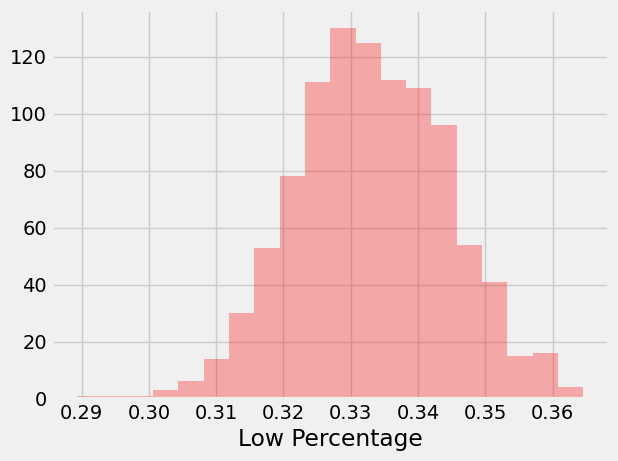

Average low percentage: 0.3331
95% Confidence Interval for low percengage: (0.3113,0.3553)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Models from scikit learn module:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data', names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep'])
df['accep'] = ~(df['accep']=='unacc') # '1' is acceptable, '0' if not acceptable
X = pd.get_dummies(df.iloc[:,0:6], drop_first=True)
y = df['accep']

x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.25)
nrows = df.shape[0]

print(nrows)
print(f'Distribution of safety ratings in {nrows} of data:')
print(round(df.safety.value_counts(normalize=True),4))

## 2. Create bootstrapped sample
boot_sample = df.sample(nrows, replace=True)
print(f'Distribution of safety ratings in bootstrapped sample data: {boot_sample.safety.value_counts()}')

## 3. Create 1000 bootstrapped samples
low_perc = []

# [ df.sample(nrows, replace=True) for i in range(1000)]
for i in range(1000):
  boot_sampe_new= df.sample(nrows, replace=True)
  #  if boot_sampe_new.safety[iloc] =='low':
  low_perc.append(boot_sampe_new.safety.value_counts(normalize=True)['low'])

## 4. Plot a histogram of the low percentage values

mean_lp =np.mean(low_perc)
plt.style.use('fivethirtyeight')
print(round(mean_lp),4)
plt.hist(low_perc, bins= 20, color = 'red', alpha = .3)

plt.xlabel('Low Percentage')
plt.show()

## 5. The 2.5 and 97.5 percentiles
print(f'Average low percentage: {np.mean(low_perc).round(4)}')

low_perc.sort()
print(f'95% Confidence Interval for low percengage: ({low_perc[25].round(4)},{low_perc[975].round(4)})')

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data', names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep'])
df['accep'] = ~(df['accep']=='unacc') #1 is acceptable, 0 if not acceptable
X = pd.get_dummies(df.iloc[:,0:6], drop_first=True)
y = df['accep']
x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.25)

#1.Decision tree trained on  training set
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(x_train, y_train)
print(f'Accuracy score of DT on test set (trained using full set): {round(dt.score(x_test, y_test), 4)}')

#2. New decision tree trained on bootstrapped sample
dt2 = DecisionTreeClassifier(max_depth=5)
#ids are the indices of the bootstrapped sample
ids = x_train.sample(x_train.shape[0], replace=True, random_state=0).index
dt2.fit(x_train.loc[ids], y_train[ids])#max_depth=50,criterion='gini')
print(f'Accuracy score of DT on test set (trained using bootstrapped sample): {round(dt2.score(x_test, y_test),4)}')

## 3. Bootstapping ten samples and aggregating the results:
preds = []
random_state = 0
#Write for loop:

for i in range(10):
  ids = x_train.sample(x_train.shape[0], replace=True, random_state=random_state+i).index
  dt2.fit(x_train.loc[ids], y_train[ids])
  preds.append(dt2.predict(x_test))

ba_pred = np.array(preds).mean(0)

# 4. Calculate accuracy of the bagged sample
ba_accuracy = accuracy_score(ba_pred>=0.5, y_test)
print(f'Accuracy score of aggregated 10 bootstrapped samples:{round(ba_accuracy,4)}')

Accuracy score of DT on test set (trained using full set): 0.8588
Accuracy score of DT on test set (trained using bootstrapped sample): 0.8912
Accuracy score of aggregated 10 bootstrapped samples:0.9097


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data', names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep'])
df['accep'] = ~(df['accep']=='unacc') #1 is acceptable, 0 if not acceptable
X = pd.get_dummies(df.iloc[:,0:6], drop_first=True)
y = df['accep']
x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.25)
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
print("Accuracy score of DT on test set (trained using full feature set):")
accuracy_dt = dt.score(x_test, y_test)
print(round(accuracy_dt,4))

# 1. Create rand_features, random samples from the set of features
rand_features = np.random.choice(x_train.columns,10)

# Make new decision tree trained on random sample of 10 features and calculate the new accuracy score
dt2 = DecisionTreeClassifier()

x_train_rand = x_train[rand_features]
x_test_rand = x_test[rand_features]
dt2.fit(x_train_rand, y_train)

print("Accuracy score of DT on test set (trained using random feature sample):")
accuracy_dt2 = dt2.score(x_test_rand, y_test)
print(round(accuracy_dt2,4))

# 2. Build decision trees on 10 different random samples
predictions = []
for i in range(10):
    rand_features = np.random.choice(x_train.columns,10)
    dt2.fit(x_train_rand, y_train)
    predictions.append(dt2.predict(x_test_rand))

## 3. Get aggregate predictions and accuracy score
prob_predictions = np.array(predictions).mean(0)

agg_predictions = (prob_predictions>0.5)
agg_accuracy = accuracy_score(agg_predictions, y_test)

print('Accuracy score of aggregated 10 samples: ', round(agg_accuracy,4))


Accuracy score of DT on test set (trained using full feature set):
0.9468
Accuracy score of DT on test set (trained using random feature sample):
0.713
Accuracy score of aggregated 10 samples:  0.713


In [8]:
from sklearn.ensemble import BaggingClassifier


df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data', names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep'])
df['accep'] = ~(df['accep']=='unacc') #1 is acceptable, 0 if not acceptable
X = pd.get_dummies(df.iloc[:,0:6], drop_first=True)
y = df['accep']
x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.25)

# 1. Bagging classifier with 10 Decision Tree base estimators
bag_dt = BaggingClassifier(estimator =DecisionTreeClassifier(max_depth=5), n_estimators=10)

bag_dt.fit(x_train, y_train)

bag_accuracy = bag_dt.score(x_test, y_test)

print('Accuracy score of Bagged Classifier, 10 estimators:', round(bag_accuracy,4) )

# 2.Set `max_features` to 10.
bag_dt_10 = BaggingClassifier(estimator = DecisionTreeClassifier(max_depth=5), n_estimators=10, max_features=10 )

bag_dt_10.fit(x_train, y_train)
bag_accuracy_10 = bag_dt_10.score(x_test, y_test)

print('Accuracy score of Bagged Classifier, 10 estimators, 10 max features:', round(bag_accuracy_10),4 )

# 3. Change base estimator to Logistic Regression
from sklearn.linear_model import LogisticRegression

bag_lr = BaggingClassifier(estimator = LogisticRegression(),n_estimators =10, max_features = 10)

bag_lr.fit(x_train, y_train)
bag_accuracy_lr = bag_lr.score(x_test, y_test)

print('Accuracy score of Logistic Regression, 10 estimators:', round(bag_accuracy_lr),4 )

Accuracy score of Bagged Classifier, 10 estimators: 0.9051
Accuracy score of Bagged Classifier, 10 estimators, 10 max features: 1 4
Accuracy score of Logistic Regression, 10 estimators: 1 4


In [11]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data', names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep'])

df['accep'] = ~(df['accep']=='unacc') #1 is acceptable, 0 if not acceptable
X = pd.get_dummies(df.iloc[:,0:6], drop_first=True)
y = df['accep']
x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.25)

# 1. Create a Random Forest Classifier and print its parameters
rf= RandomForestClassifier()
rf_params = rf.get_params()
print('Random Forest parameters:', rf_params)

# 2. Fit the Random Forest Classifier
# alculate accuracy score on the test data

rf.fit(x_train, y_train)
y_pred= rf.predict(x_test)
rf_accuracy=rf.score(x_test, y_test)

print('Test set accuracy:')
print(rf_accuracy)

# 3. Calculate Precision and Recall scores and the Confusion Matrix
rf_precision =precision_score(y_test, y_pred)
print(f'Test set precision: {rf_precision}')

rf_recall = recall_score(y_test, y_pred)
print(f'Test set recall: {rf_recall}')

rf_confusion_matrix = confusion_matrix(y_test, y_pred)

print(f'Test set confusion matrix:\n{rf_confusion_matrix}')


print(f'Test set confusion matrix:\n{rf_confusion_matrix} ',rf_confusion_matrix)


Random Forest parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Test set accuracy:
0.9583333333333334
Test set precision: 0.9538461538461539
Test set recall: 0.9117647058823529
Test set confusion matrix:
[[290   6]
 [ 12 124]]
Test set confusion matrix:
[[290   6]
 [ 12 124]]  [[290   6]
 [ 12 124]]


In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data', names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep'])
df['accep'] = ~(df['accep']=='unacc') #1 is acceptable, 0 if not acceptable
X = pd.get_dummies(df.iloc[:,0:6], drop_first=True)

## Generating some fake prices for regression! :)
fake_prices = (15000 + 25*df.index.values)+np.random.normal(size=df.shape[0])*5000
df['price'] = fake_prices
print(df.price.describe())
y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.25)

# 1. Create a Random Regressor and print `R^2` scores on training and test data

rfr= RandomForestRegressor()
rfr.fit(x_train, y_train)
r_squared_train=rfr.score(x_train, y_train)
r_squared_test=rfr.score(x_test, y_test)

# print('Random Forest parameters:', rf_params)

print(f'Train set R^2: {r_squared_train:.4f}')
print(f'Test set R^2: {r_squared_test:.4f}')


# 2. Print Mean Absolute Error on training and test data
avg_price=df.price.mean()
# avg_price = y.mean()
print(f'Avg Price Train/Test: {avg_price}')

y_pred_train =rfr.predict(x_train)
y_pred_test =rfr.predict(x_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
print(f'Train set MAE: {mae_train}')

mae_test = mean_absolute_error(y_test, y_pred_test)
print(f'Test set MAE: {mae_test}')

count     1728.000000
mean     36745.428431
std      13433.349484
min       6323.502771
25%      25767.810357
50%      36550.747251
75%      47573.848318
max      68452.273080
Name: price, dtype: float64
Train set R^2: round(0.9788946239102031,4)
Test set R^2: round(0.8163773421596563,4)
Avg Price Train/Test: 36745.42843130059
Train set MAE: 1560.1043964524204
Test set MAE: 4612.013238760018


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
param_grid = {'n_estimators': [100, 200, 200, 500],
              'max_depth':[5,10,15,20],
              # 'max_features': [5,10,15,20],
              'min_samples_split':[2,5,10]}
from sklearn.model_selection import RandomizedSearchCV

grid_search = RandomizedSearchCV(RandomForestRegressor(random_state=0), param_grid, cv=5,
                                 verbose=4, n_jobs=-1)
grid_search.fit(x_train, y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=0),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 200, 500]},
                   verbose=4)

In [24]:
grid_search.best_params_

{'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 5}

In [25]:
grid_search.best_score_

np.float64(0.8655865618789067)

In [28]:
%%time
from sklearn.metrics import mean_absolute_error, mean_squared_error

rf = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_split=2)
rf.fit(x_train, y_train)

print(f'Training R²: {rf.score(x_train, y_train):.4f}')
print(f'Testing R²: {rf.score(x_test, y_test):.4f}')

y_pred_train = rf.predict(x_train)
y_pred_test = rf.predict(x_test)

print(f'Train MAE: {mean_absolute_error(y_train, y_pred_train):.2f}')
print(f'Test MAE: {mean_absolute_error(y_test, y_pred_test):.2f}')

print(f'Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}')

Training R²: 0.8817
Testing R²: 0.8501
Train MAE: 3715.80
Test MAE: 4121.51
Train RMSE: 4628.92
Test RMSE: 5165.26
CPU times: user 1.58 s, sys: 6.86 ms, total: 1.58 s
Wall time: 1.65 s
